<a href="https://colab.research.google.com/github/cohench123/cohen_INFO4670_Spring2026/blob/main/Assignment3_AssociationRuleMining_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [51]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import fpgrowth, association_rules
import networkx as nx

datafile = pad.read_csv("bread_basket.csv")
datafile.head()

,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


**I successfully loaded the dataset by placing the .csv file into the files folder for this project. I imported pandas, matplotlib, mlxtend, and networkx.**

## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [52]:
# write your answer here
datafile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   transaction      20507 non-null  int64 
 1   item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   time             20507 non-null  object
 4   period_day       20507 non-null  object
 5   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(5)
memory usage: 961.4+ KB


**Transaction is int64, item, data_time, time, period_day, weekday_weekend are all objects**

### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for RapidMiner's Statistics. Take a screenshot when you submit.

In [53]:
# write your answer here
datafile.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**. Take a screenshot of the figure.

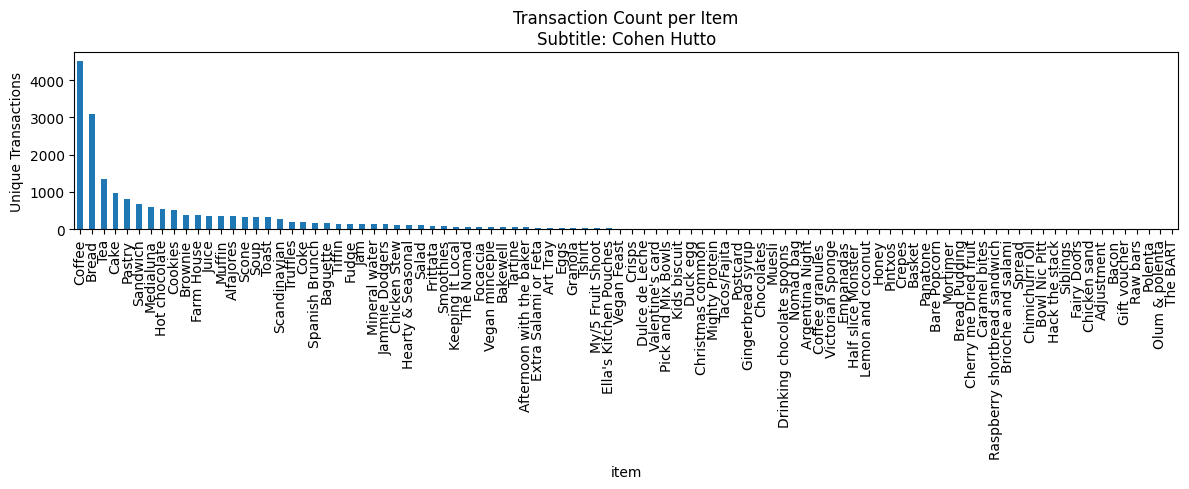

In [54]:
# c) Bar plot of transaction counts per item
subtitle = "Cohen Hutto"  # <-- EDIT THIS
item_counts =  (
    datafile.groupby("item")["transaction"]
    .nunique()
    .sort_values(ascending=False)
)

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [57]:
# write your answer here
items = {"Coffee", "Tea", "Alfajores", "Juice", "Chicken Stew"}

counts = (
    datafile[datafile["item"].isin(items)]
    .groupby("item")["transaction"]
    .nunique()
)
counts

,transaction
item,
Alfajores,344
Chicken Stew,123
Coffee,4528
Juice,365
Tea,1350


**Coffee = 4528, Tea = 1350, Alfajores = 344, Juice = 365, Chicken Stew = 123**

## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.2) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [58]:
# write your answer here
# Creating the transaction x item matrix
basket = (
    datafile.groupby(['transaction', 'item'])['item']
    .count()
    .unstack()
    .fillna(0)
)

# Converting basket to a boolean
basket = basket.astype(bool)

# Using FPGrowth with min_support of 0.01 to see the relationship of coffe, cake, bread
frequent_itemsets = fpgrowth(basket, min_support=0.01, use_colnames=True)
frequent_itemsets.sort_values("support", ascending=False)

,support,itemsets
6,0.478394,(Coffee)
0,0.327205,(Bread)
9,0.142631,(Tea)
16,0.103856,(Cake)
30,0.090016,"(Coffee, Bread)"
...,...,...
14,0.010565,(Hearty & Seasonal)
26,0.010460,(Salad)
55,0.010354,"(Bread, Alfajores)"
49,0.010037,"(Tea, Cake, Coffee)"


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

Filtered rules: 44


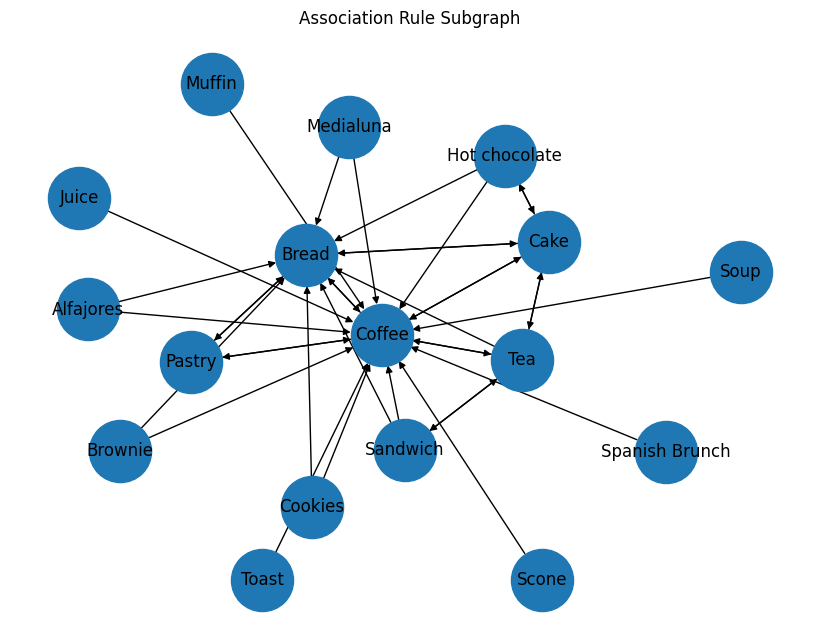

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
29,"(Coffee, Cake)",(Tea),0.054728,0.142631,0.010037,0.183398,1.285822,1.0,0.002231,1.049923,0.235157,0.053582,0.047549,0.126884
30,"(Coffee, Cake)",(Bread),0.054728,0.327205,0.010037,0.183398,0.560497,1.0,-0.007870,0.823895,-0.453411,0.026989,-0.213747,0.107036


In [59]:
# write your answer here
# Creating the rules with the min_threshold of 0.6
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.1
)

rules.sort_values("lift", ascending=False)

# Filtering rules based on bread, coffee, cake, tea
i_items = {"Bread", "Coffee", "Cake", "Tea"}

filtered_rules = rules[
    rules['antecedents'].apply(lambda x: any(item in i_items for item in x)) |
    rules['consequents'].apply(lambda x: any(item in i_items for item in x))
]

print("Filtered rules:", len(filtered_rules))

# Creating the graph
G = nx.DiGraph()

for _, row in filtered_rules.iterrows():
    for a in row['antecedents']:
        for c in row['consequents']:
            G.add_edge(a, c, weight=row['lift'])

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=2000)
plt.title("Association Rule Subgraph")
plt.show()
rules[rules['antecedents'].apply(lambda x: x == {'Coffee','Cake'})]

## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:*

**Support: The fraction of all transactions that contain coffee, cake, and bread together is 0.010037 or 1.0037%**

**Confidence: Among the baskets with coffee and cake, the sahre that also includes bread is 0.183398 or 18.34%**

**Lift: The lift is 0.560497 which is less than 1 so there is negative association.**

**The rule means that if a customer is buying coffee and cake then they are less likely to also buy bread.**

>